# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import lightgbm as lgb

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse,r2_score
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings('ignore')

# Data Loading

In [2]:
df = pd.read_csv('medical_cost.csv')
df.head()

,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,female,27.900,0,yes,southwest,16884.92400
1,2,18,male,33.770,1,no,southeast,1725.55230
2,3,28,male,33.000,3,no,southeast,4449.46200
3,4,33,male,22.705,0,no,northwest,21984.47061
4,5,32,male,28.880,0,no,northwest,3866.85520


# Understanding Data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Id        1338 non-null   int64  
 1   age       1338 non-null   int64  
 2   sex       1338 non-null   str    
 3   bmi       1338 non-null   float64
 4   children  1338 non-null   int64  
 5   smoker    1338 non-null   str    
 6   region    1338 non-null   str    
 7   charges   1338 non-null   float64
dtypes: float64(2), int64(3), str(3)
memory usage: 83.8 KB


In [4]:
df.describe()

,Id,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,669.500000,39.207025,30.663397,1.094918,13270.422265
std,386.391641,14.049960,6.098187,1.205493,12110.011237
min,1.000000,18.000000,15.960000,0.000000,1121.873900
25%,335.250000,27.000000,26.296250,0.000000,4740.287150
50%,669.500000,39.000000,30.400000,1.000000,9382.033000
75%,1003.750000,51.000000,34.693750,2.000000,16639.912515
max,1338.000000,64.000000,53.130000,5.000000,63770.428010


# EDA

## Mean charge by categorical columns

In [5]:
categorical_cols = ['sex', 'children', 'smoker', 'region']

for col in categorical_cols:
    grouped_data = df[[col, 'charges']].groupby(col).mean()
    print(f"Mean charges by {col}:")
    print(grouped_data)
    print()

Mean charges by sex:
             charges
sex                 
female  12569.578844
male    13956.751178

Mean charges by children:
               charges
children              
0         12365.975602
1         12731.171832
2         15073.563734
3         15355.318367
4         13850.656311
5          8786.035247

Mean charges by smoker:
             charges
smoker              
no       8434.268298
yes     32050.231832

Mean charges by region:
                charges
region                 
northeast  13406.384516
northwest  12417.575374
southeast  14735.411438
southwest  12346.937377



## Visualizing categorical columns distribution

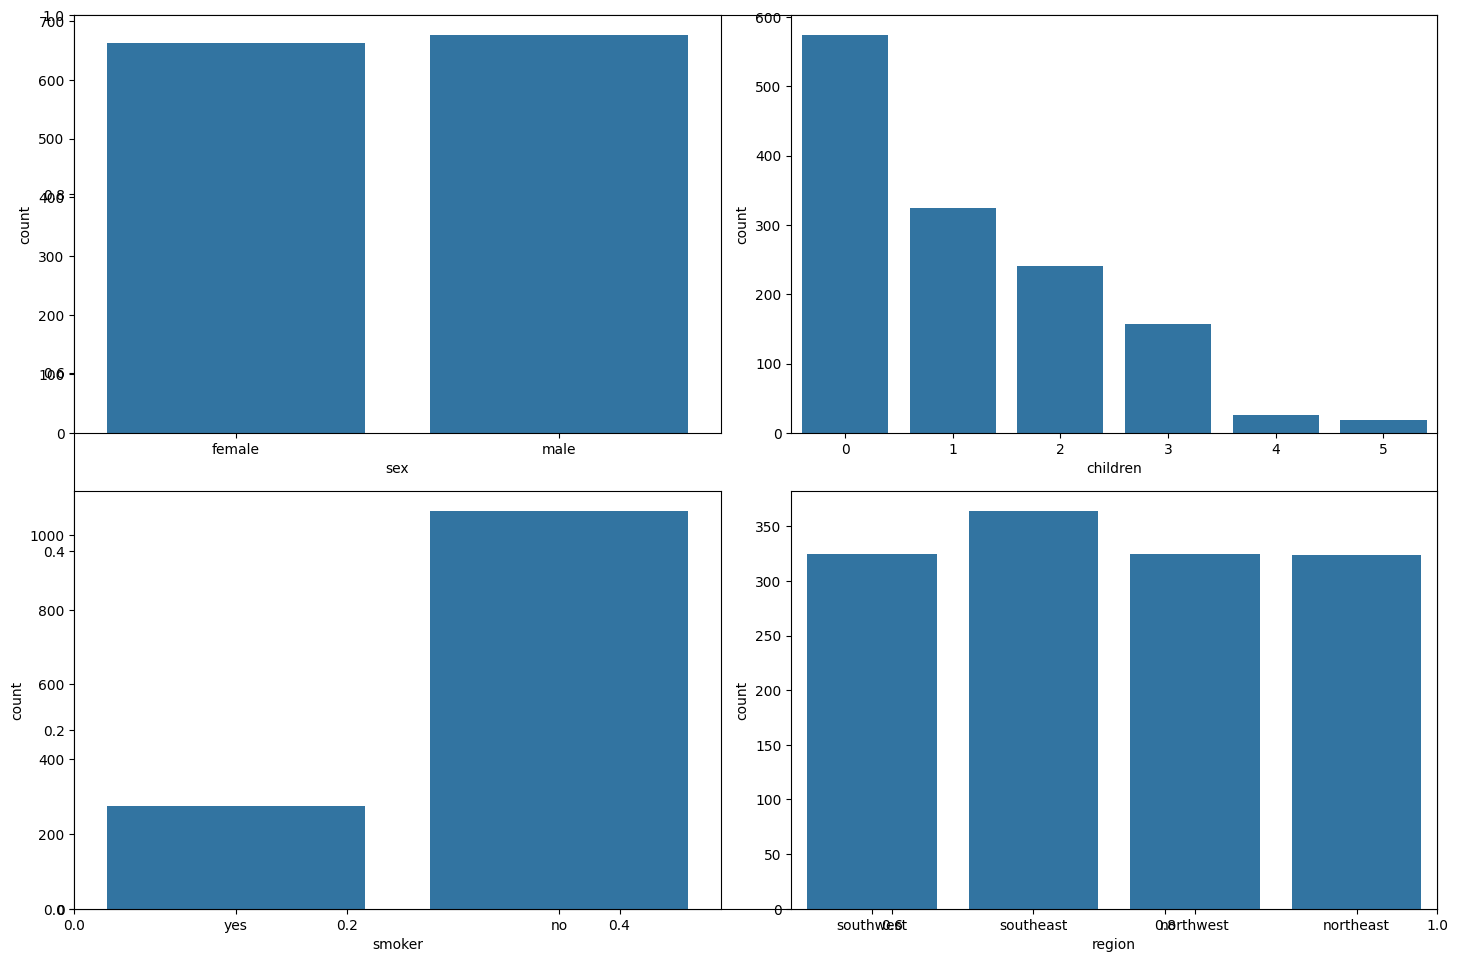

In [6]:
plt.subplots(figsize=(15, 10))

for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1)
    sb.countplot(data=df, x=col)
plt.tight_layout()
plt.show()

## Visualizing Numerical columns distribution

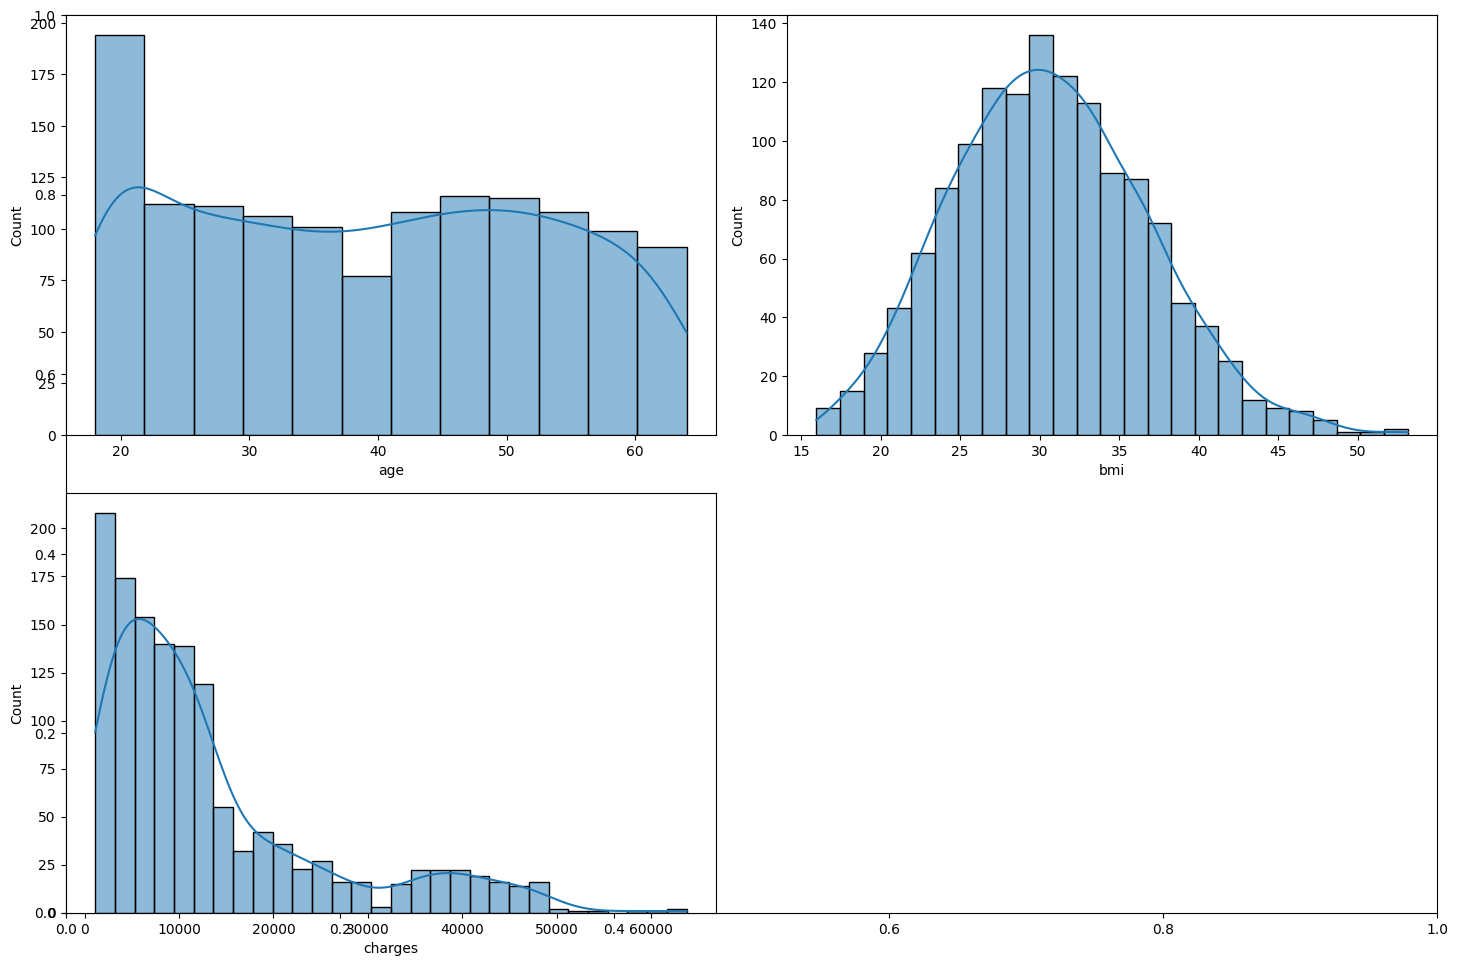

In [7]:
numeric_cols = ['age', 'bmi', 'charges']

plt.subplots(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 2, i + 1)
    sb.histplot(df[col], kde=True)
plt.tight_layout()
plt.show()

## Insights from EDA

- Men have slightly higher charges than women
- No clear trend between number of children and charges
- Smokers have significantly higher charges than non-smokers
- Charges vary slightly across regions

# Data preprocessing

## Log transformation

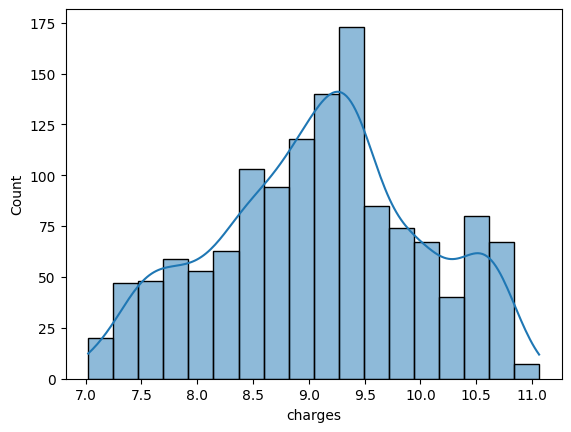

In [8]:
df['charges'] = np.log1p(df['charges']) #for skewness of target variables
sb.histplot(df['charges'], kde=True)
plt.show()

## Encoding of categorical features

In [9]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
df.head()

,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,1,27.900,0,1,southwest,9.734236
1,2,18,0,33.770,1,0,southeast,7.453882
2,3,28,0,33.000,3,0,southeast,8.400763
3,4,33,0,22.705,0,0,northwest,9.998137
4,5,32,0,28.880,0,0,northwest,8.260455


In [10]:
# applying one hot encoding
# as more than 2 categories which are Nominal data type

df = pd.concat([df, pd.get_dummies(df['region']).astype('int')], axis=1)
df.drop(['Id', 'region'], inplace=True, axis=1)
df.head()

,age,sex,bmi,children,smoker,charges,northeast,northwest,southeast,southwest
0,19,1,27.900,0,1,9.734236,0,0,0,1
1,18,0,33.770,1,0,7.453882,0,0,1,0
2,28,0,33.000,3,0,8.400763,0,0,1,0
3,33,0,22.705,0,0,9.998137,0,1,0,0
4,32,0,28.880,0,0,8.260455,0,1,0,0


# Testing and Training datasets

In [11]:
features = df.drop('charges', axis=1)
target = df['charges']

X_train, X_val, Y_train, Y_val = train_test_split(features, target, test_size=0.25, random_state=42)

# Feature Scaling

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Data preparation

In [13]:
train_data = lgb.Dataset(X_train, label=Y_train)
test_data = lgb.Dataset(X_val, label=Y_val, reference=train_data)

# Model training

In [14]:
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9
}

num_round = 100
bst = lgb.train(params, train_data, num_round, valid_sets=[test_data])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001482 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 328
[LightGBM] [Info] Number of data points in the train set: 1003, number of used features: 9
[LightGBM] [Info] Start training from score 9.102650


In [15]:
model = LGBMRegressor(metric='rmse')
model.fit(X_train, Y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000724 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 328
[LightGBM] [Info] Number of data points in the train set: 1003, number of used features: 9
[LightGBM] [Info] Start training from score 9.102650


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# Model Evaluation

In [16]:
y_train = model.predict(X_train)
y_val = model.predict(X_val)

print("Training RMSE   : ", np.sqrt(mse(Y_train, y_train)))
print("Average RMSE    : ", np.sqrt((Y_val - np.mean(Y_val)) ** 2).mean())
print("Validation RMSE : ", np.sqrt(mse(Y_val, y_val)))

Training RMSE   :  0.23258791721523056
Average RMSE    :  0.7573984024348771
Validation RMSE :  0.4033332942810217


In [17]:
r2 = r2_score(Y_val, y_val)

print("Validation R2 Score :", r2)

Validation R2 Score : 0.8116571011994531


In [18]:
import joblib

joblib.dump(model, 'medical_cost_prediction_model.pkl')

['medical_cost_prediction_model.pkl']